In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [31]:
df = pd.read_csv('heart_attack_prediction_indonesia.csv')
df.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,smoking_status,alcohol_consumption,physical_activity,dietary_habits,air_pollution_exposure,stress_level,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,Never,NaN,High,Unhealthy,Moderate,Moderate,5.970603,113,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,Past,NaN,Moderate,Healthy,High,High,5.643813,132,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,Past,Moderate,Moderate,Healthy,Low,Low,6.336197,116,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,Never,Moderate,Moderate,Unhealthy,Low,High,7.912990,136,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,Current,Moderate,Moderate,Unhealthy,High,Moderate,3.252338,127,75,104,59,127,139,Normal,1,0,1,1


In [32]:
df.shape

(158355, 28)

In [33]:
df.isna().sum()

age                                   0
gender                                0
region                                0
income_level                          0
hypertension                          0
diabetes                              0
cholesterol_level                     0
obesity                               0
waist_circumference                   0
family_history                        0
smoking_status                        0
alcohol_consumption               94848
physical_activity                     0
dietary_habits                        0
air_pollution_exposure                0
stress_level                          0
sleep_hours                           0
blood_pressure_systolic               0
blood_pressure_diastolic              0
fasting_blood_sugar                   0
cholesterol_hdl                       0
cholesterol_ldl                       0
triglycerides                         0
EKG_results                           0
previous_heart_disease                0


In [34]:
df['alcohol_consumption'].fillna('No Alcohol', inplace=True)

C:\Users\BUDI\AppData\Local\Temp\ipykernel_33344\3340498423.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_consumption'].fillna('No Alcohol', inplace=True)


# EDA

In [35]:
numeric_cols=['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
categoric_cols = df[df.columns.difference(numeric_cols)].columns.tolist()
print("Categoric columns:", categoric_cols)
print("Numeric columns:", numeric_cols)

Categoric columns: ['EKG_results', 'air_pollution_exposure', 'alcohol_consumption', 'diabetes', 'dietary_habits', 'family_history', 'gender', 'heart_attack', 'hypertension', 'income_level', 'medication_usage', 'obesity', 'participated_in_free_screening', 'physical_activity', 'previous_heart_disease', 'region', 'smoking_status', 'stress_level']
Numeric columns: ['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']


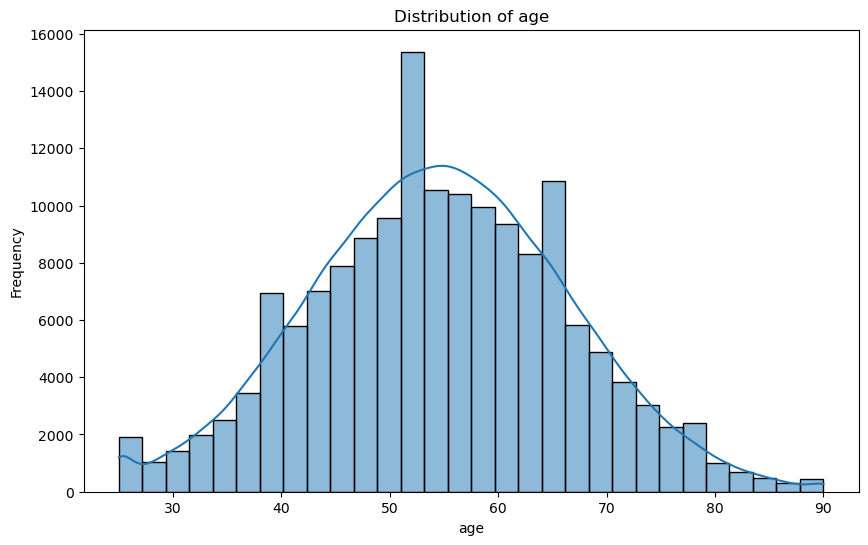

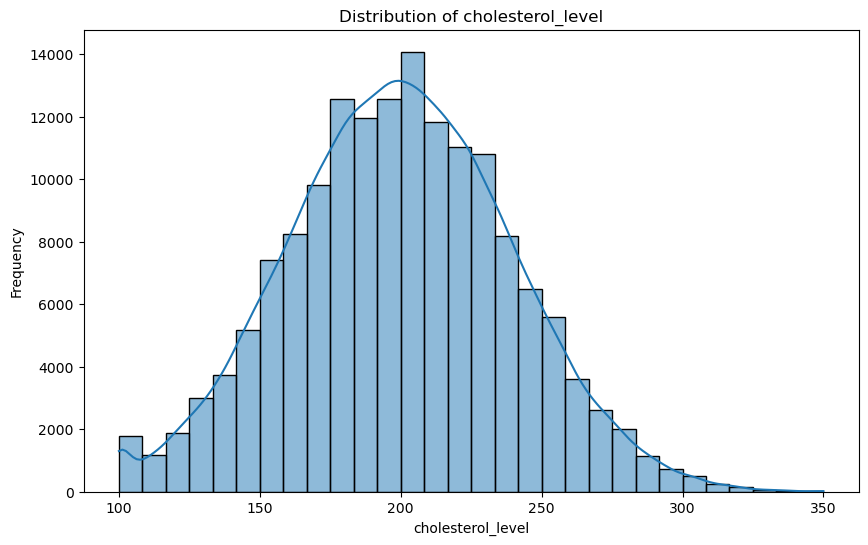

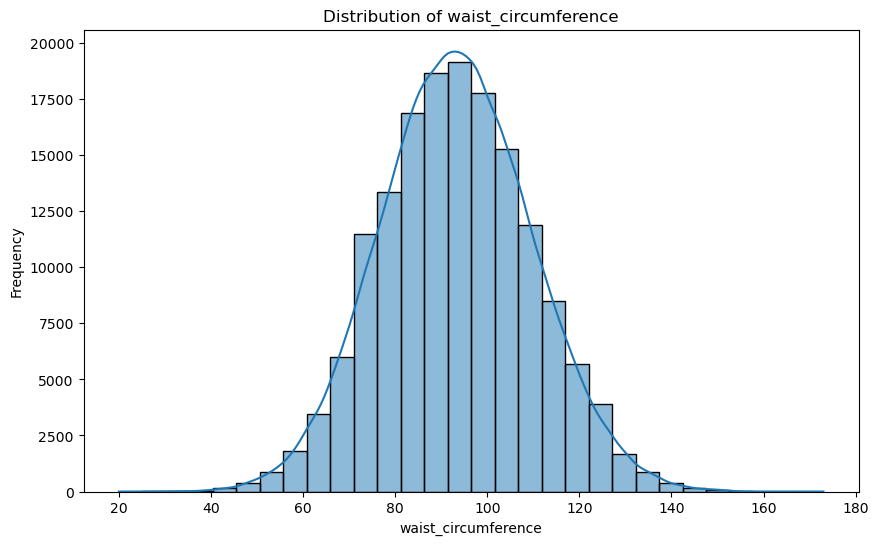

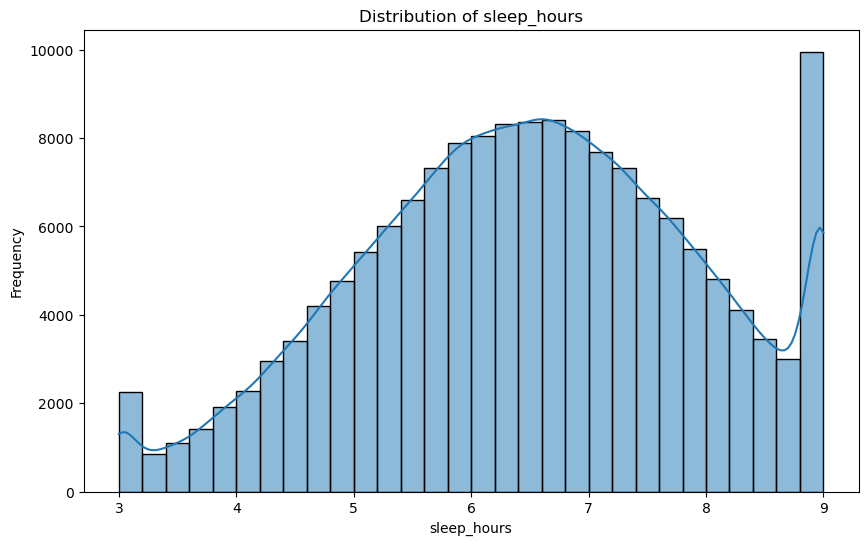

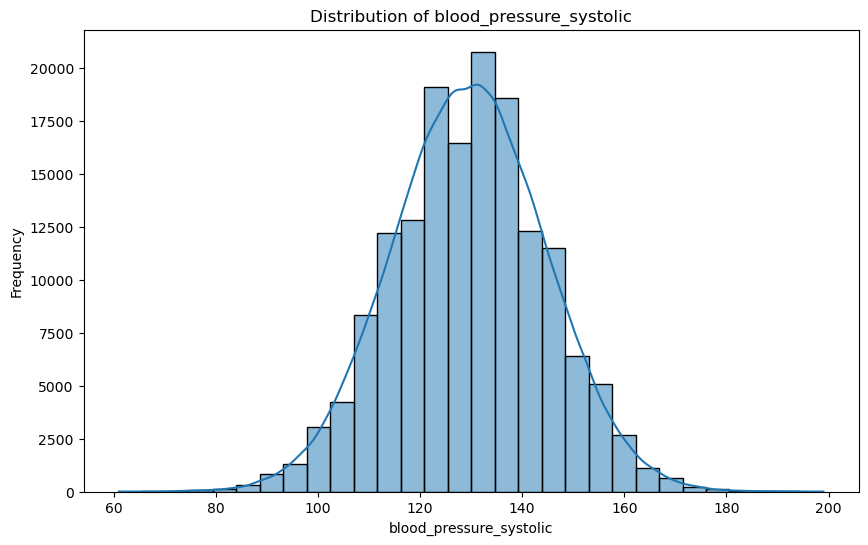

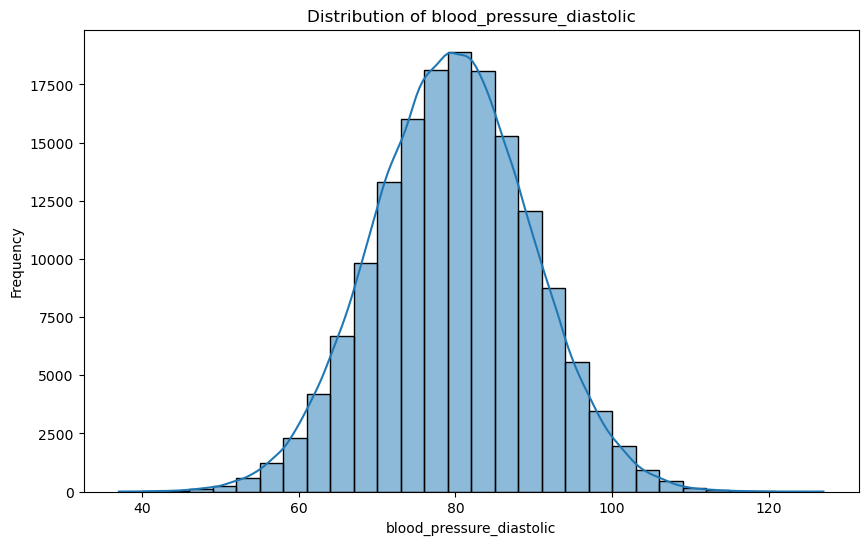

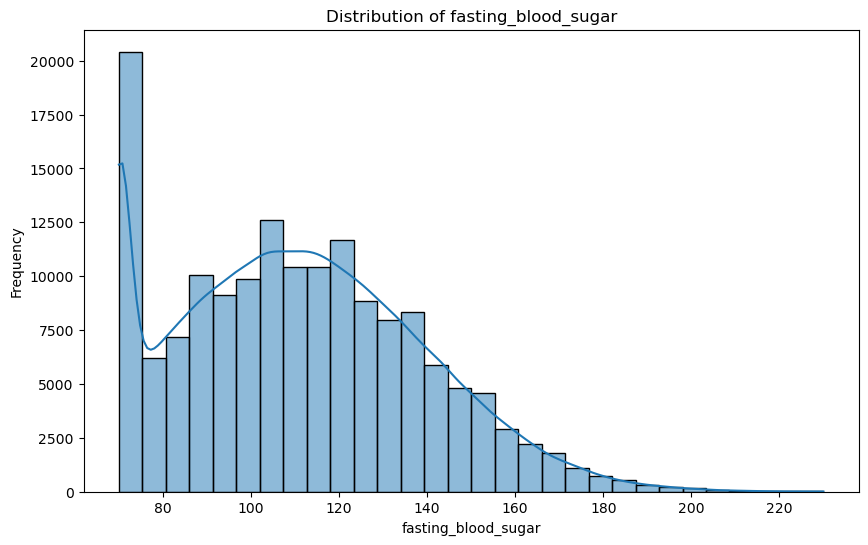

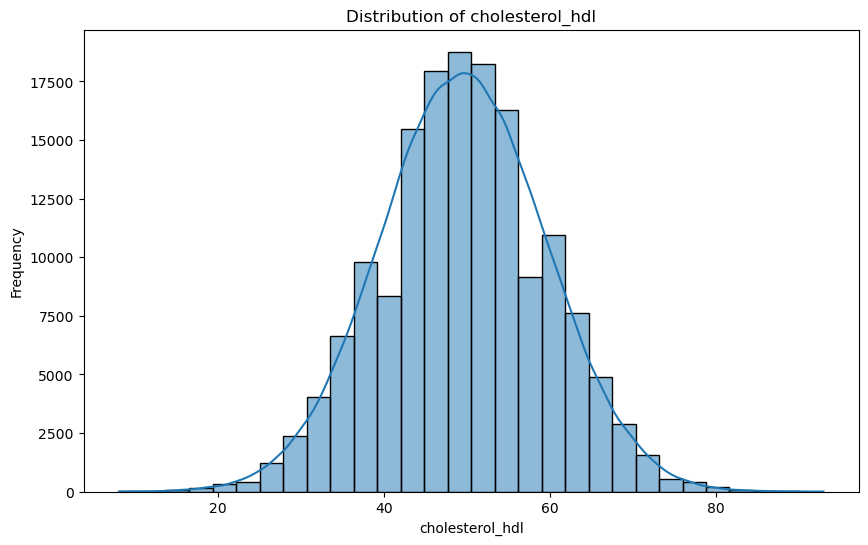

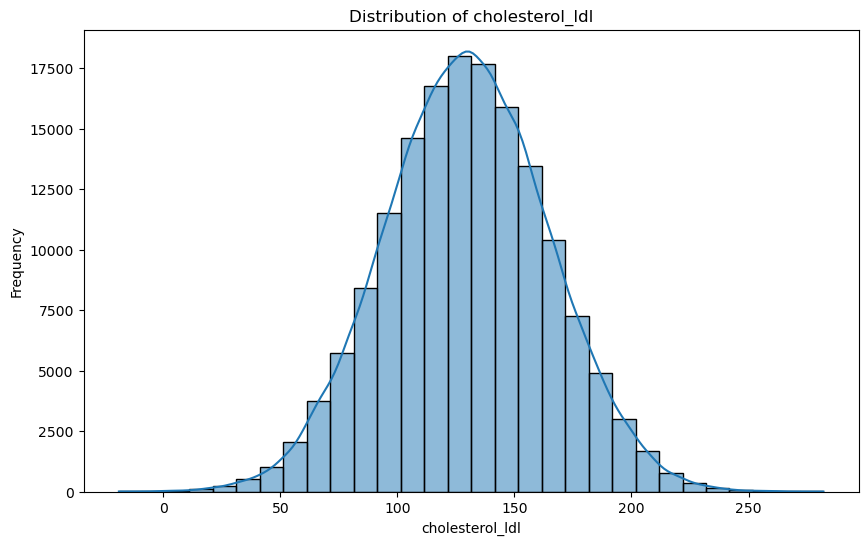

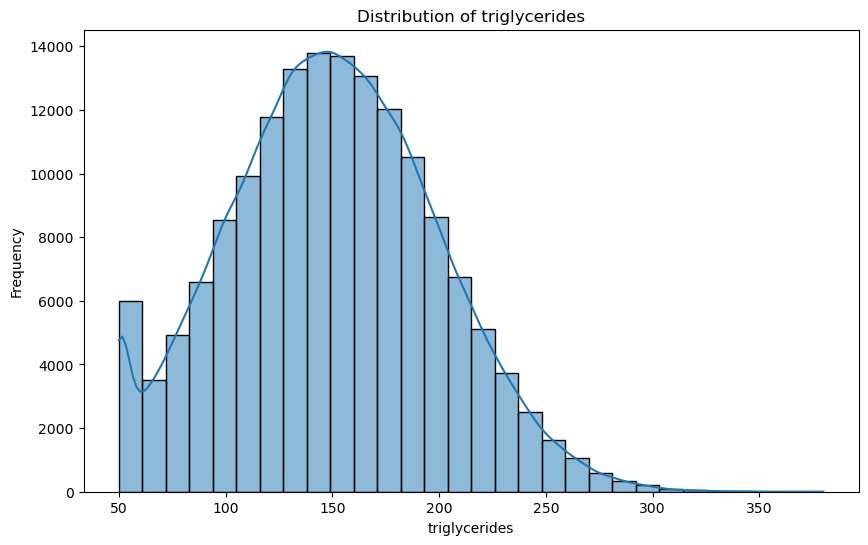

In [36]:
# Plotting the distribution of numeric columns
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

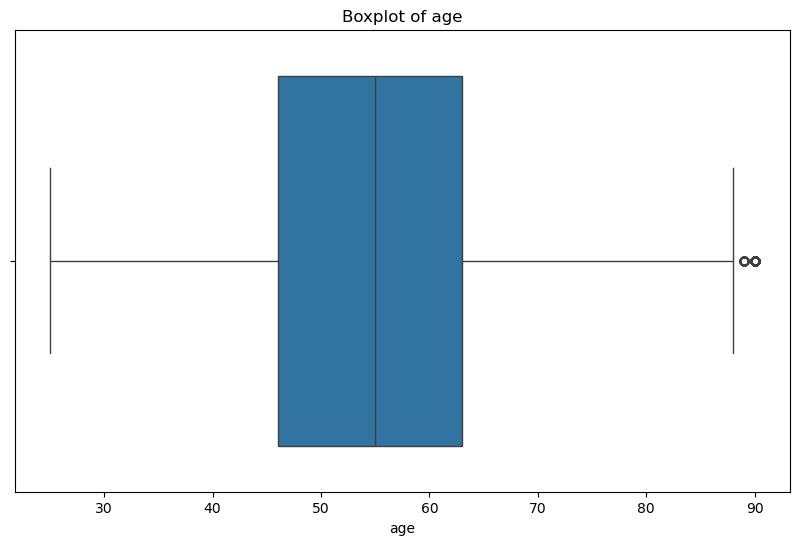

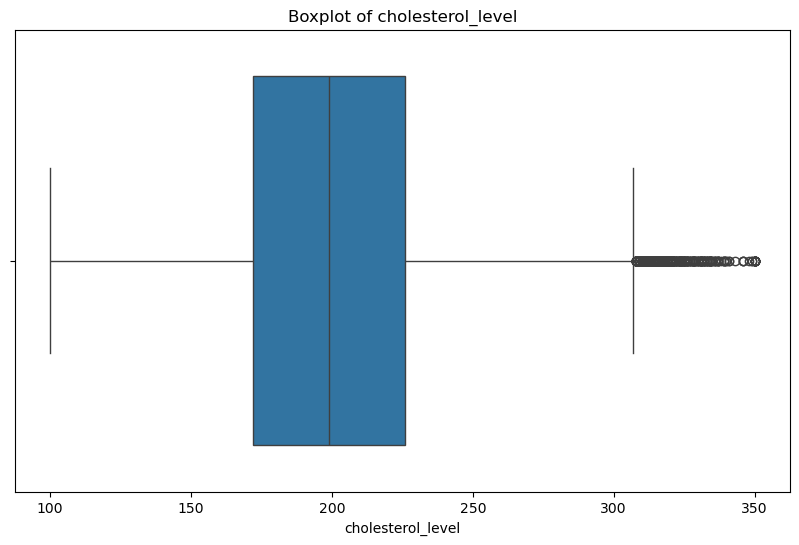

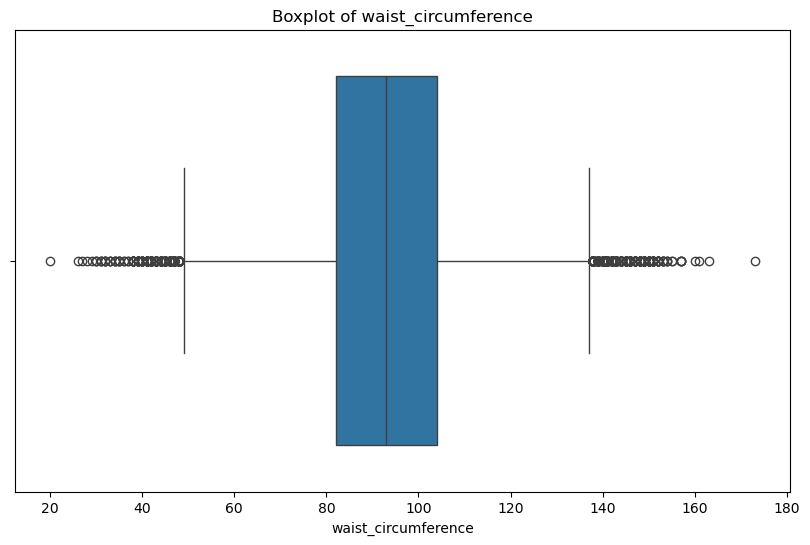

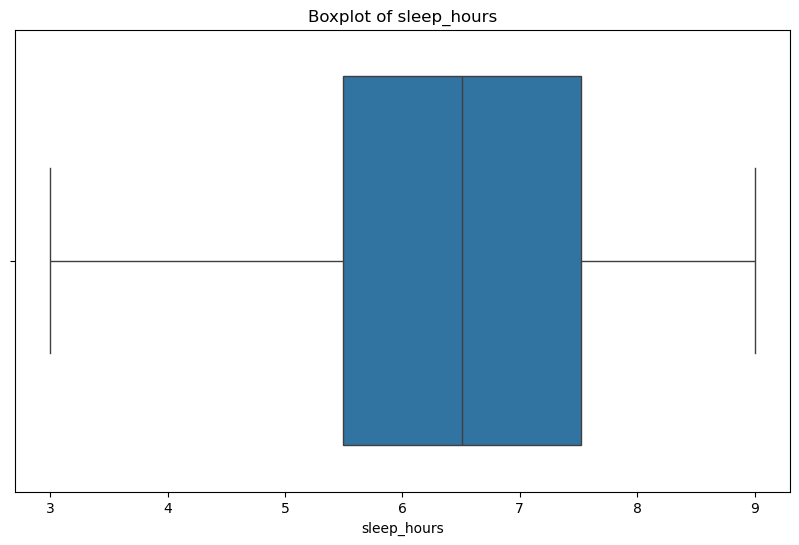

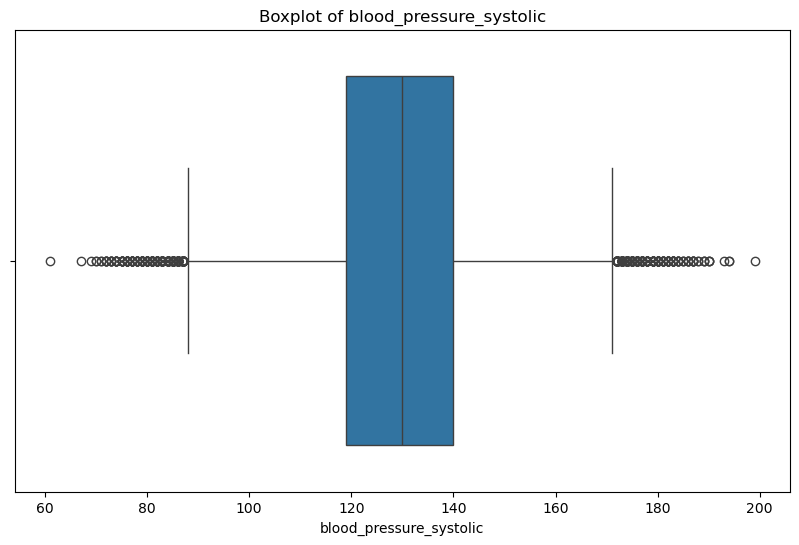

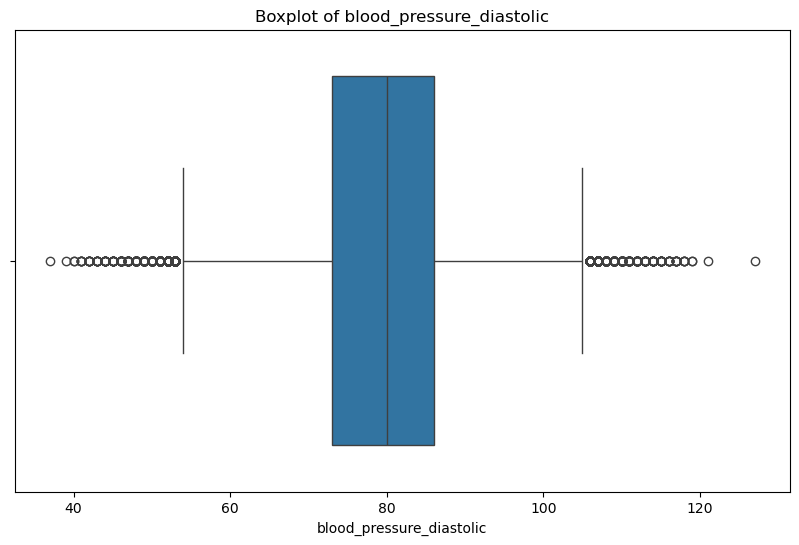

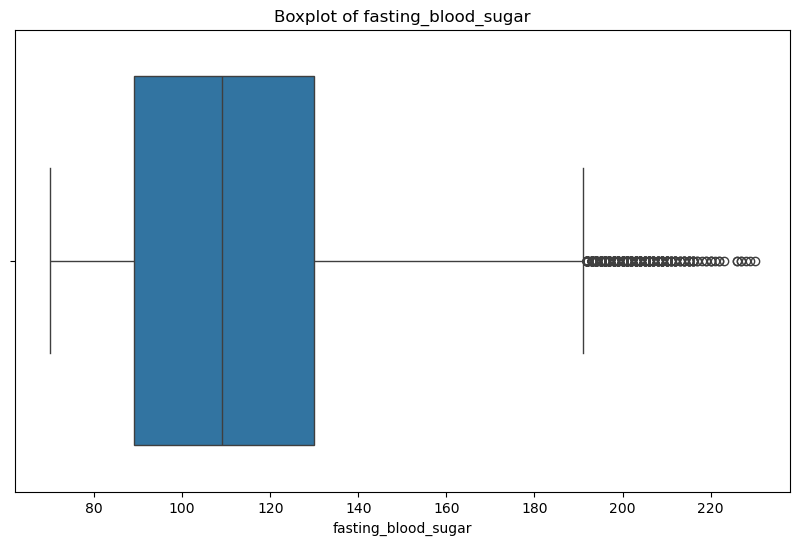

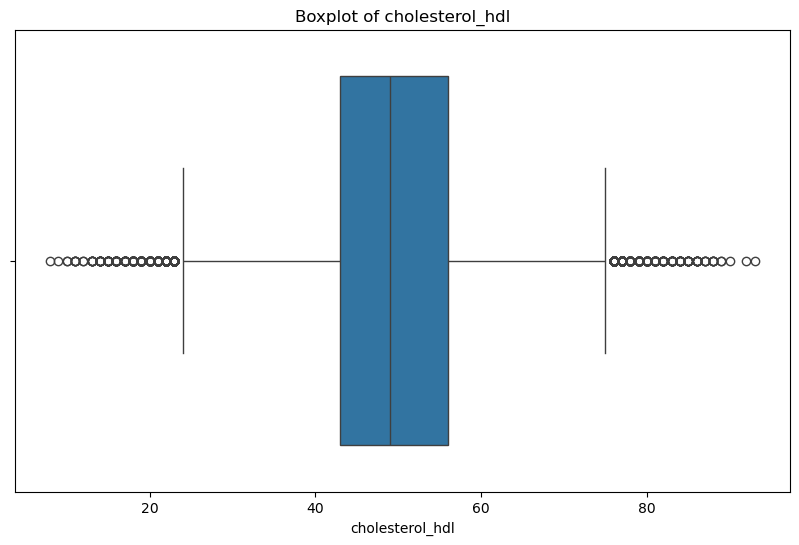

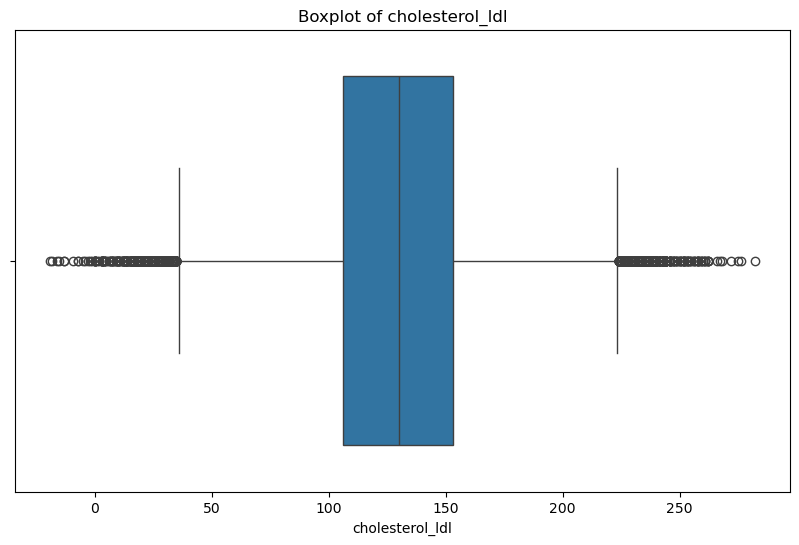

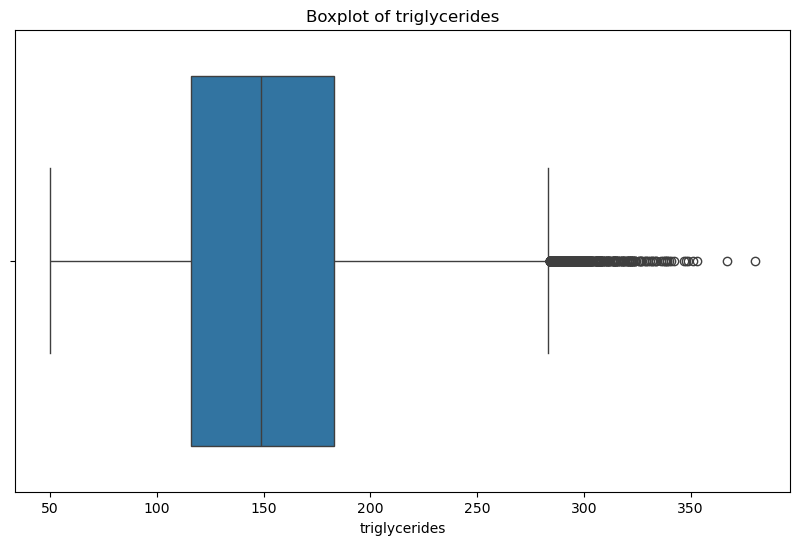

In [37]:
# boxplot for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

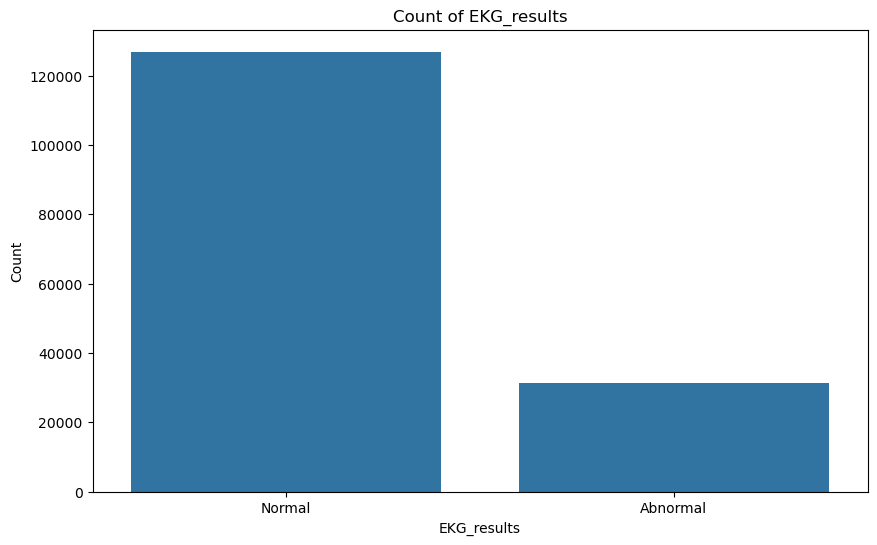

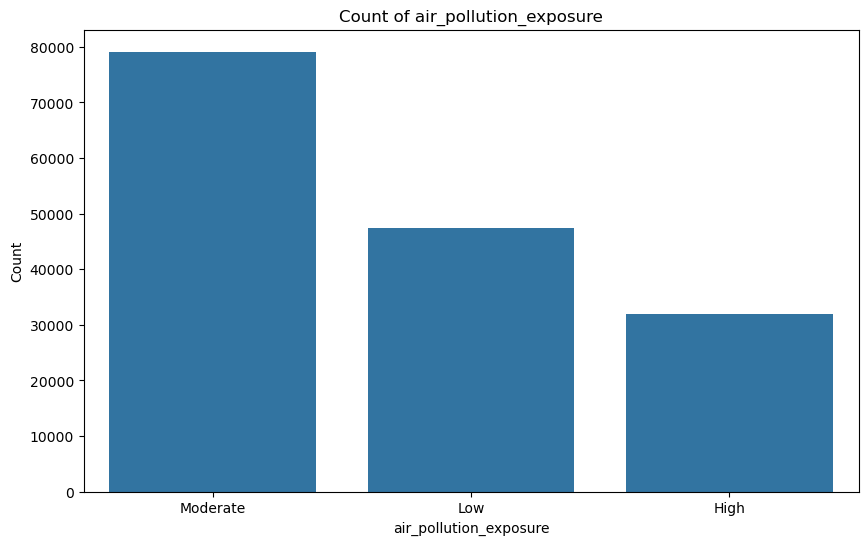

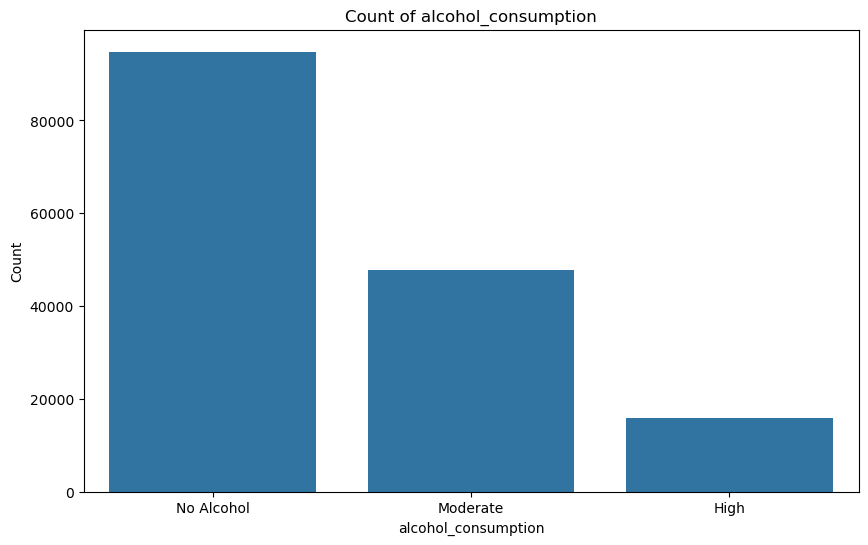

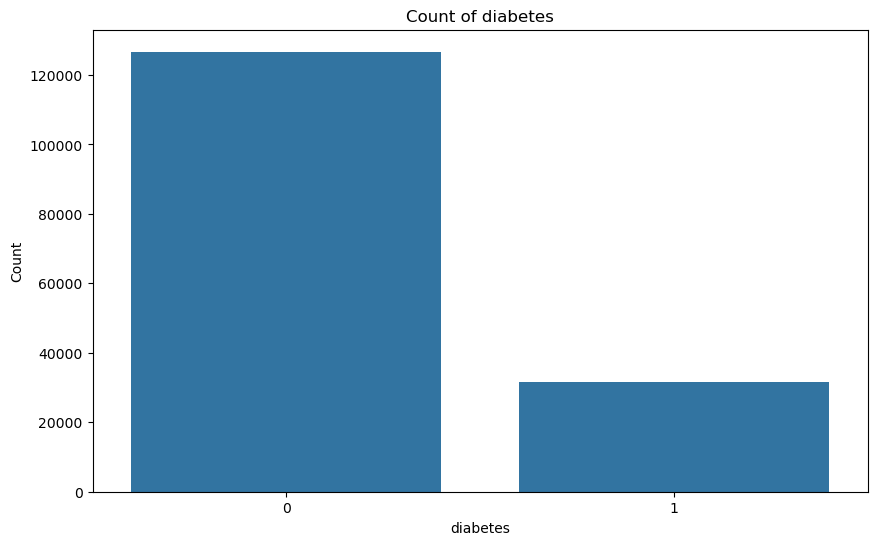

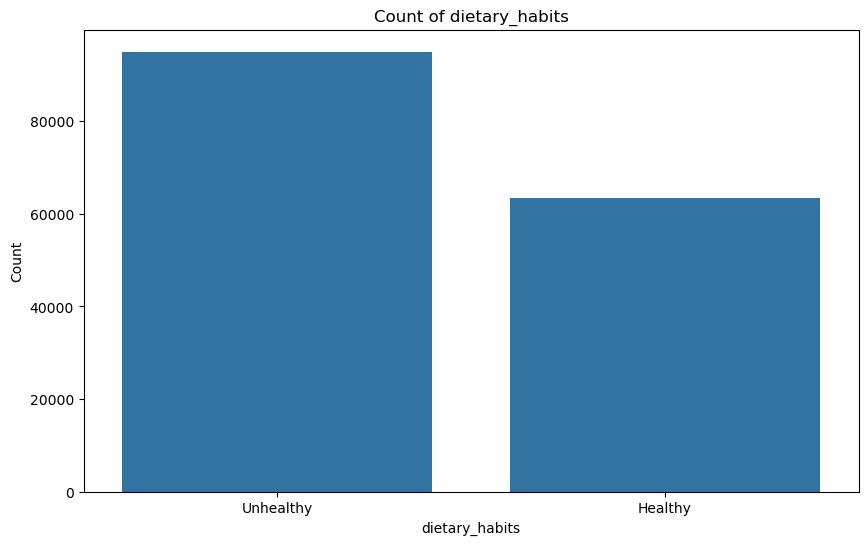

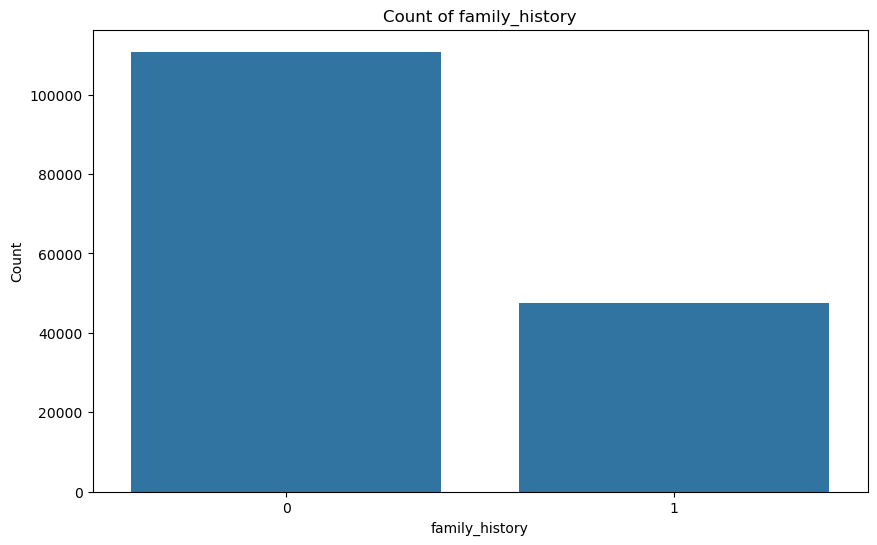

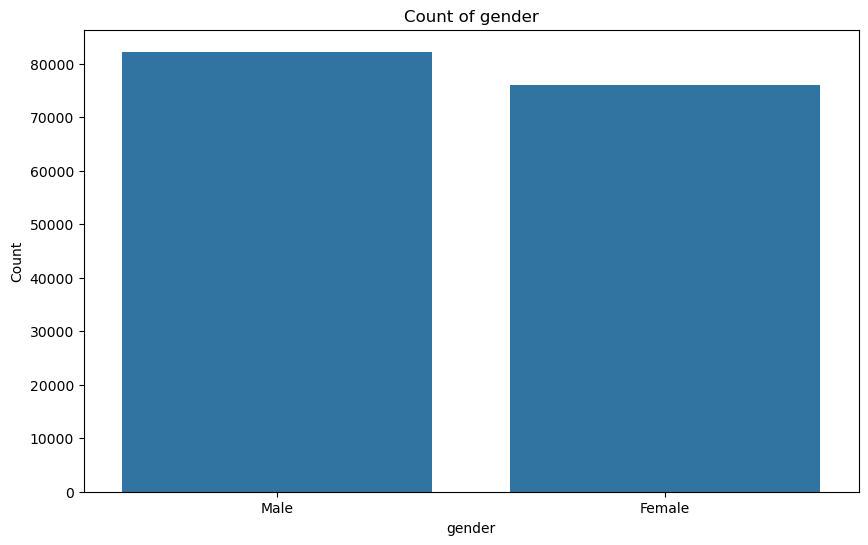

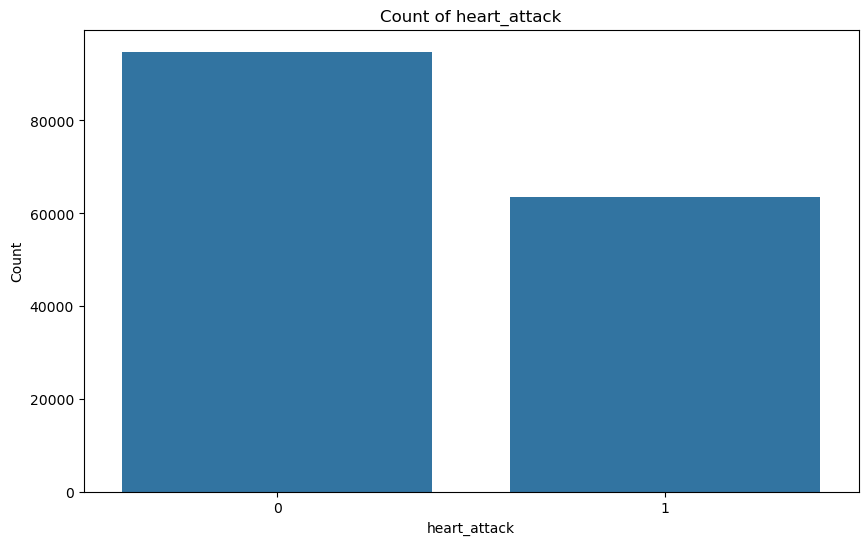

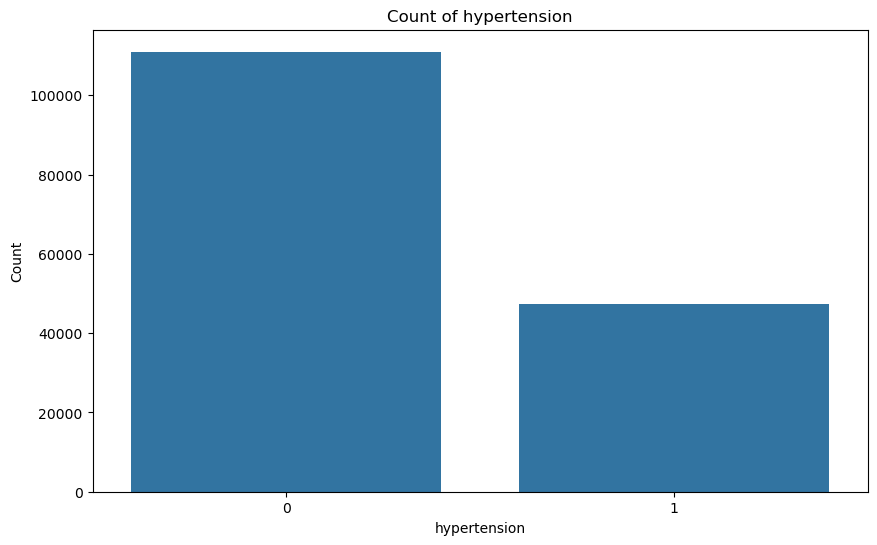

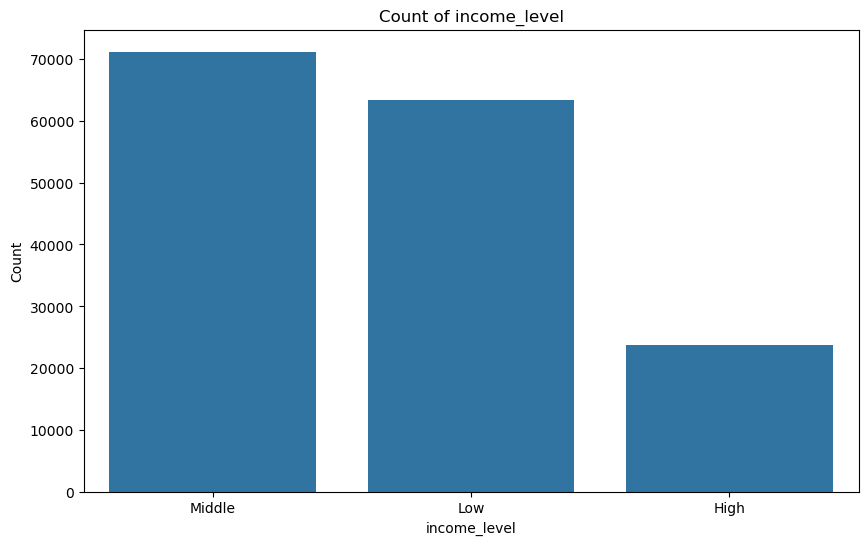

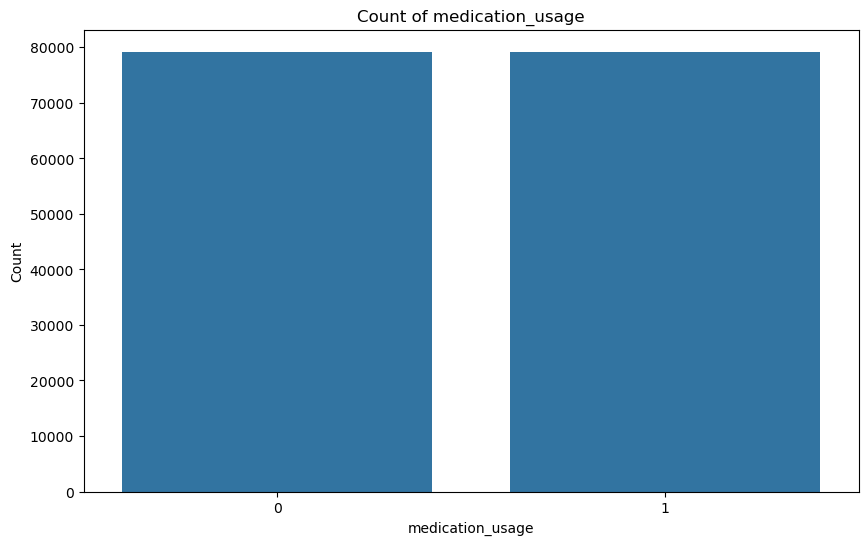

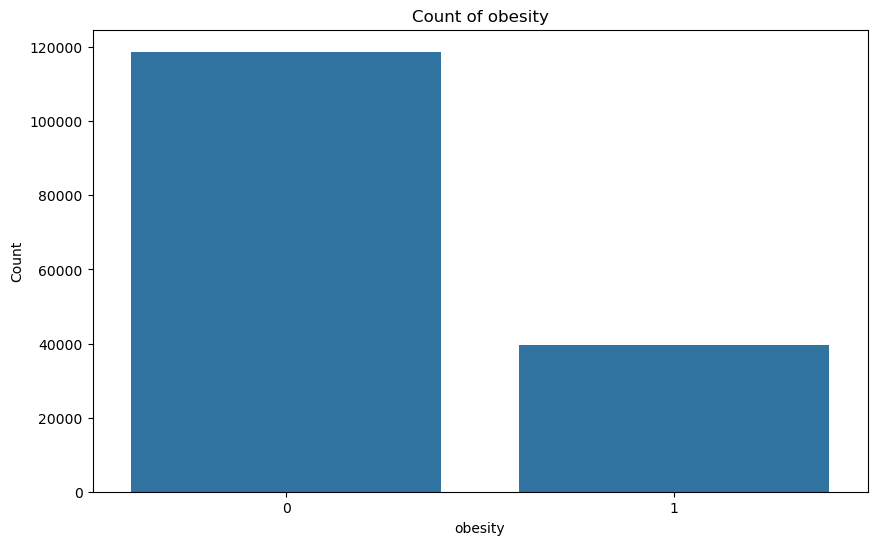

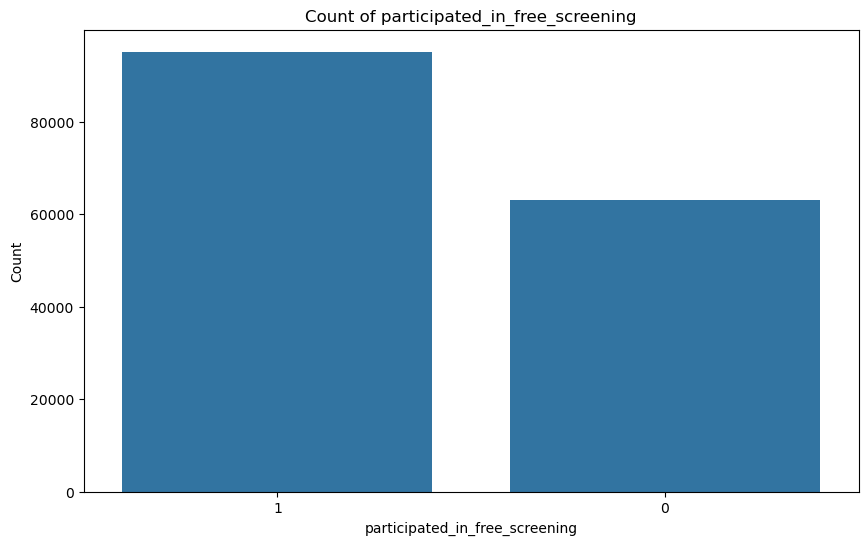

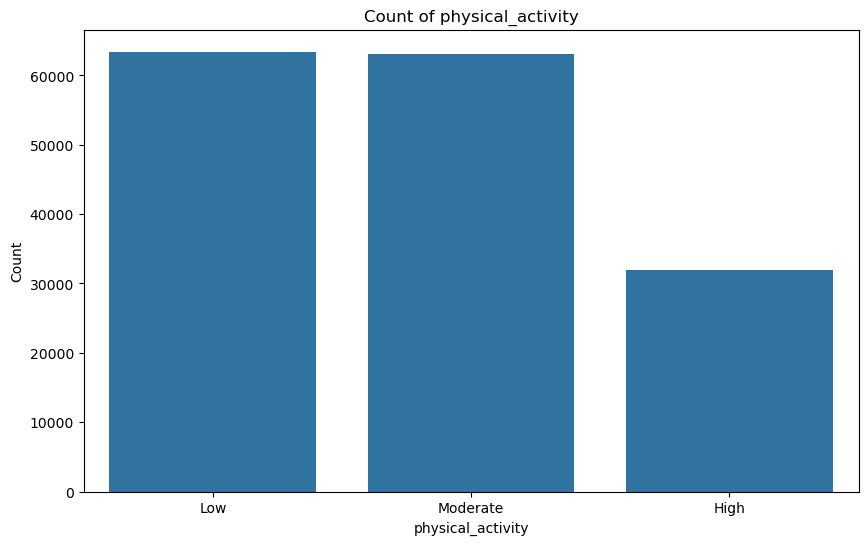

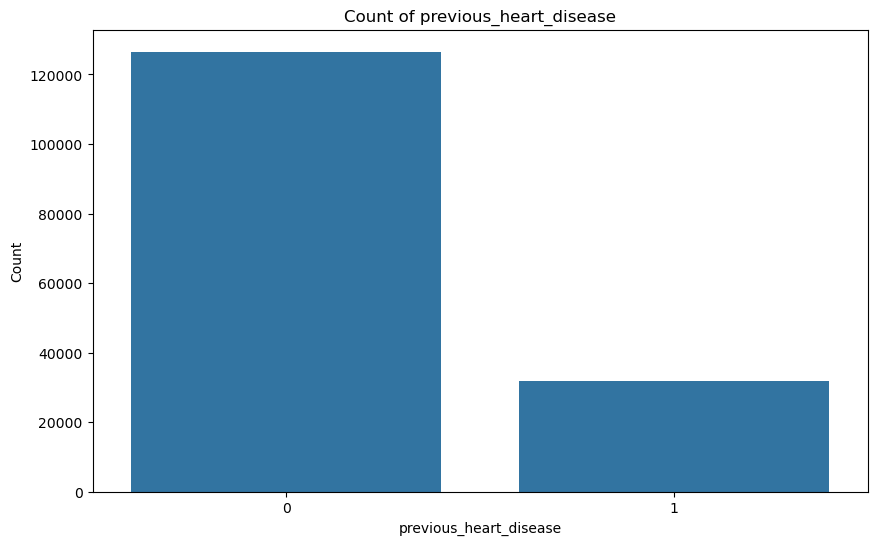

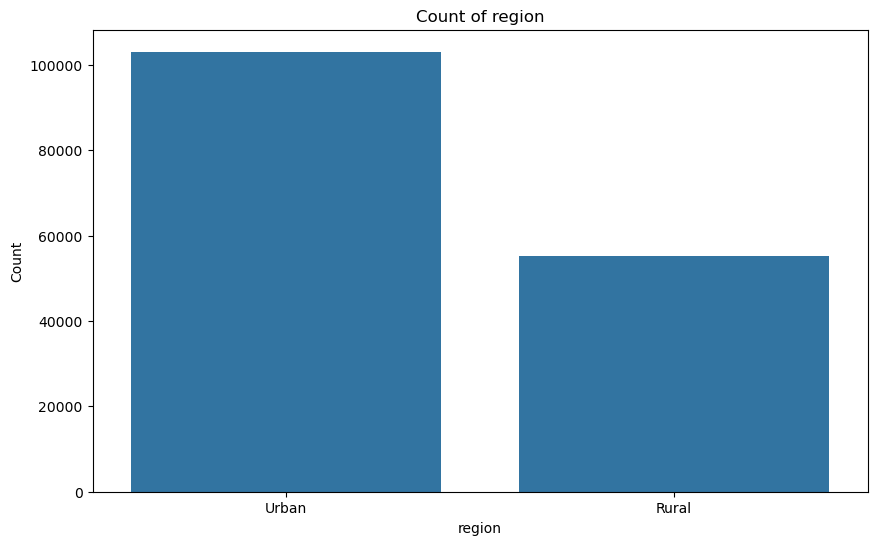

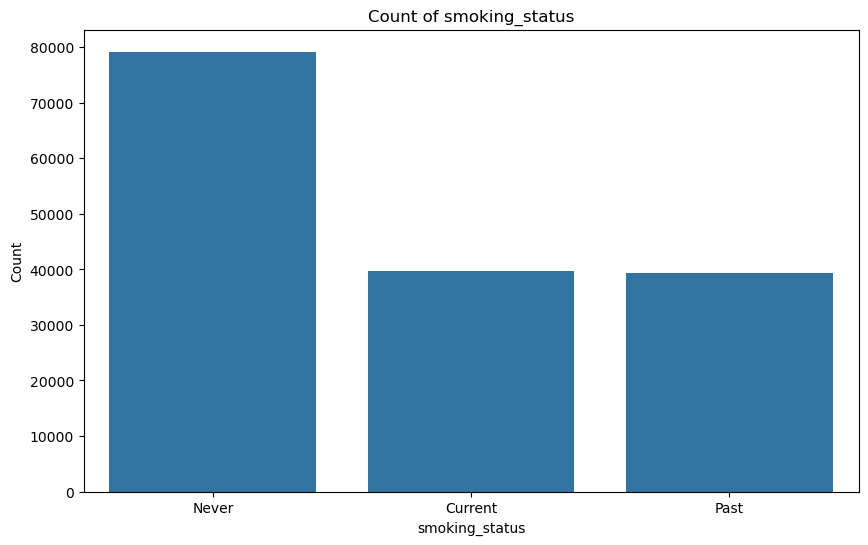

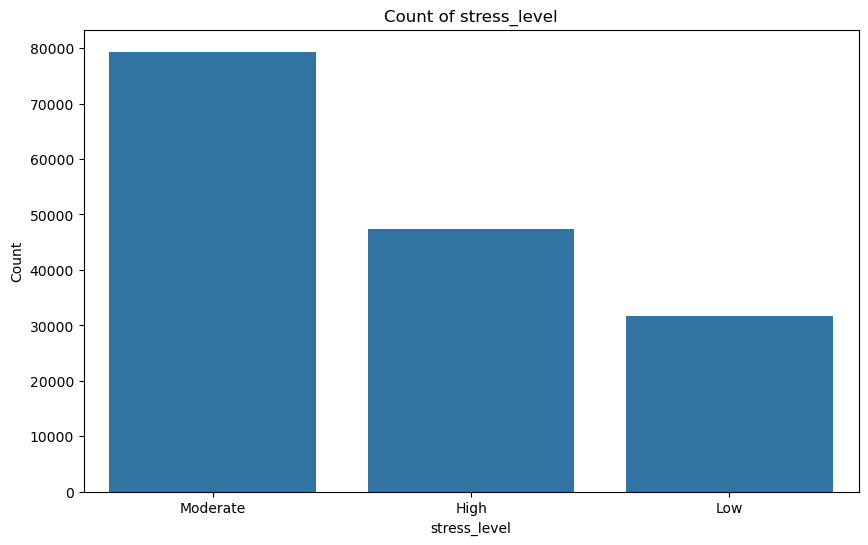

In [38]:
for col in categoric_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Feature engineering

In [39]:
# hapus outlier
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
df_cleaned.shape


(157786, 28)

In [43]:
# encoding categoric columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categoric_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
# Check the cleaned DataFrame
df_cleaned.head()

C:\Users\BUDI\AppData\Local\Temp\ipykernel_33344\918583011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col])
C:\Users\BUDI\AppData\Local\Temp\ipykernel_33344\918583011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = le.fit_transform(df_cleaned[col])
C:\Users\BUDI\AppData\Local\Temp\ipykernel_33344\918583011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,smoking_status,alcohol_consumption,physical_activity,dietary_habits,air_pollution_exposure,stress_level,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,1,0,2,0,1,211,0,83,0,1,2,0,1,2,2,5.970603,113,62,173,48,121,101,1,0,0,0,0
1,53,0,1,1,0,0,208,0,106,1,2,2,2,0,0,0,5.643813,132,76,70,58,83,138,1,1,0,1,0
2,62,0,1,1,0,0,231,1,112,1,2,1,2,0,1,1,6.336197,116,74,118,69,130,171,0,0,1,0,1
3,73,1,1,1,1,0,202,0,82,1,1,1,2,1,1,0,7.912990,136,65,98,52,85,146,1,0,1,1,0
4,52,1,1,2,1,0,232,0,89,0,0,1,2,1,0,2,3.252338,127,75,104,59,127,139,1,1,0,1,1


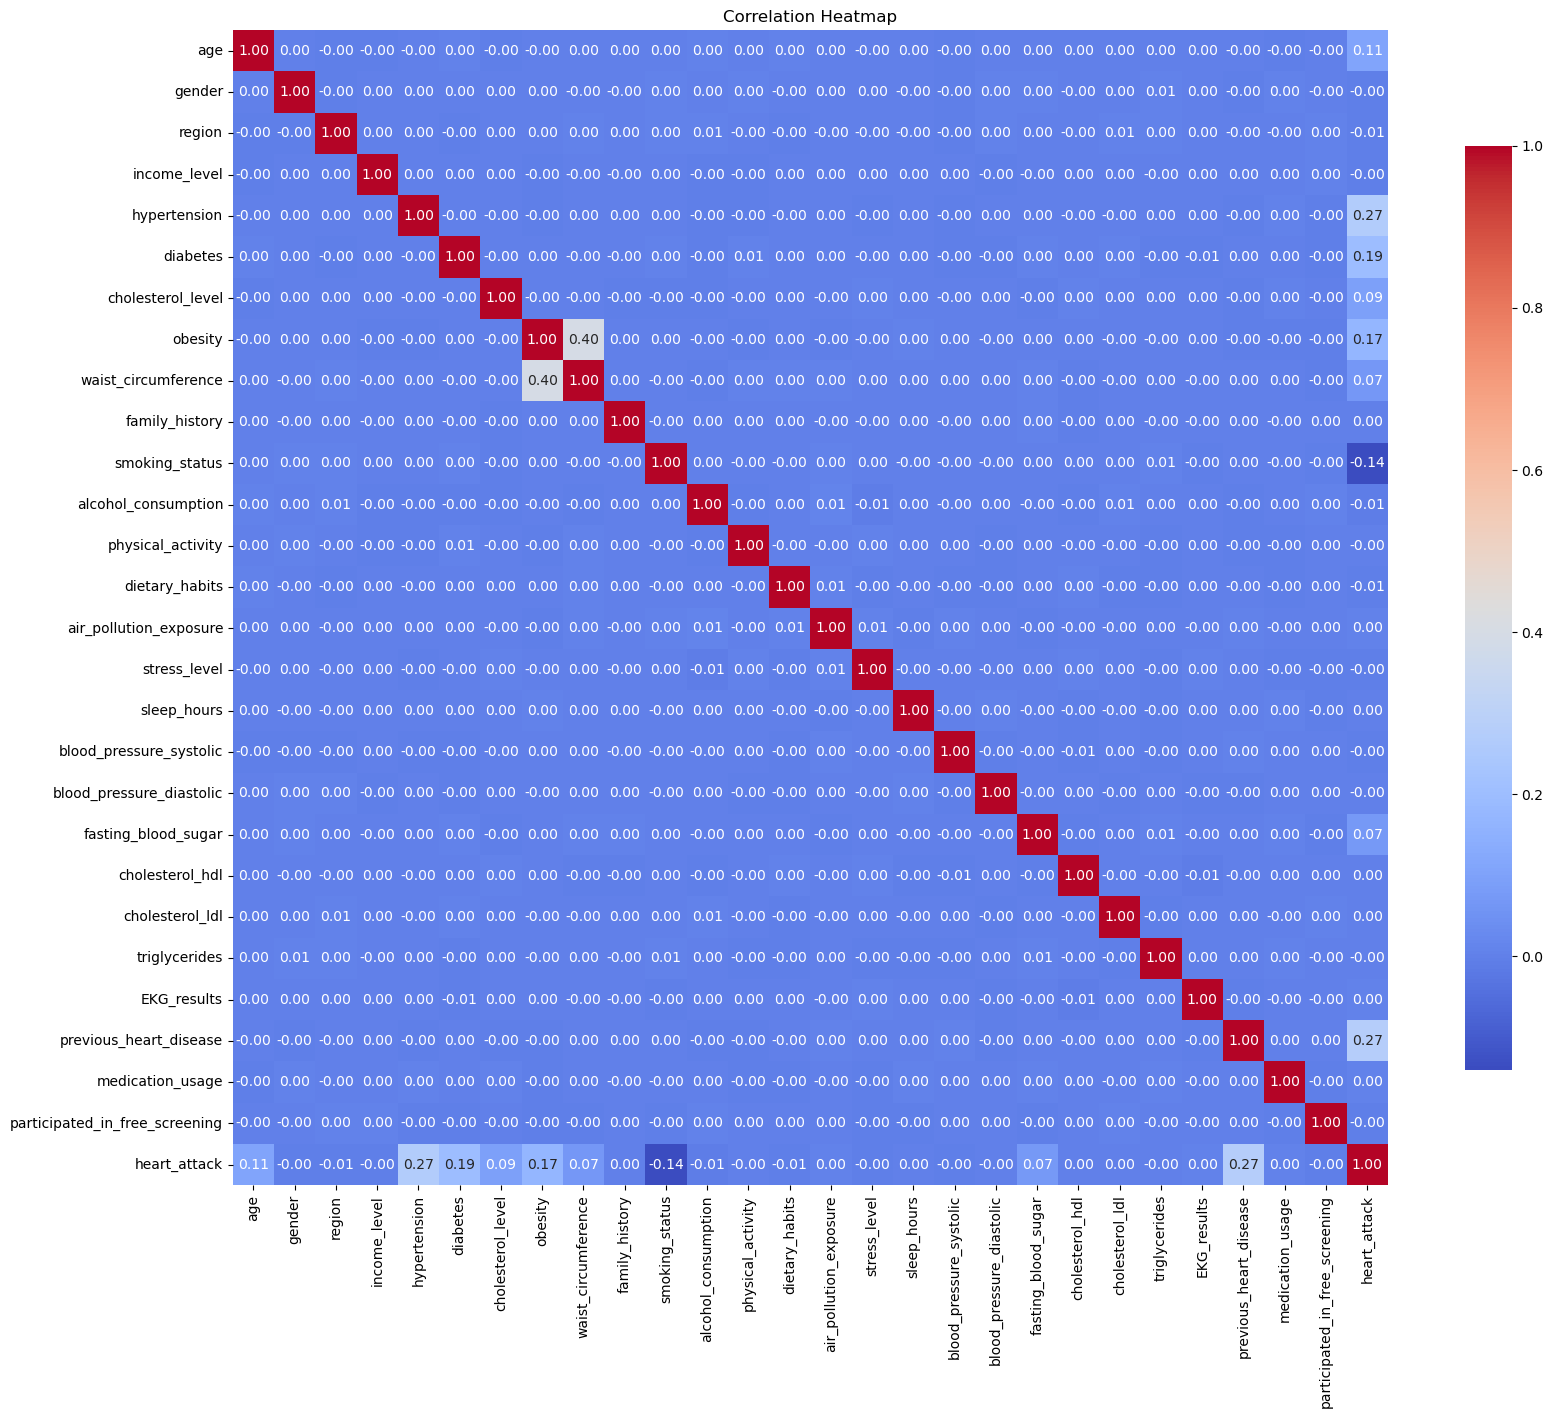

In [45]:
# heatmap to visualize correlations
plt.figure(figsize=(20, 15))
sns.heatmap(df_cleaned.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.show()

In [47]:
# splitting the dataset into features and target variable
X = df_cleaned.drop('heart_attack', axis=1)
y = df_cleaned['heart_attack']

In [48]:
# standardizing the numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Sahoo G. K. et al. compared the performance of LR, KNN, SVM, NB, DT, RF, and XG Boost Machine Learning models for predicting heart disease. The Cleveland heart disease dataset from the UCI ML repository was used to train the models. Comparing the results of the tested ML algorithms, the RF algorithm performed the best, with a classification accuracy of 90.16% <br>
https://pmc.ncbi.nlm.nih.gov/articles/PMC10378171/#B17-diagnostics-13-02392

# Modelling

Accuracy: 0.7290385956017491
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79     18984
           1       0.69      0.58      0.63     12574

    accuracy                           0.73     31558
   macro avg       0.72      0.70      0.71     31558
weighted avg       0.73      0.73      0.72     31558

Confusion Matrix:
 [[15725  3259]
 [ 5292  7282]]


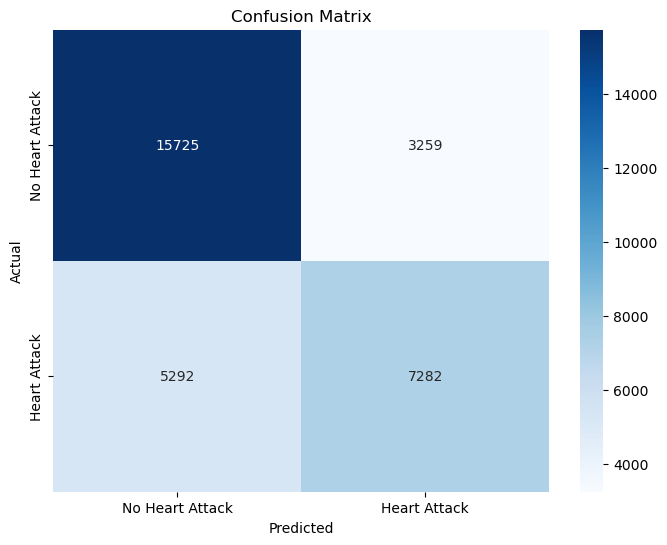

In [51]:
# training logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# evaluating the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest Accuracy: 0.7337600608403574
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79     18984
           1       0.69      0.60      0.64     12574

    accuracy                           0.73     31558
   macro avg       0.72      0.71      0.71     31558
weighted avg       0.73      0.73      0.73     31558

Random Forest Confusion Matrix:
 [[15655  3329]
 [ 5073  7501]]


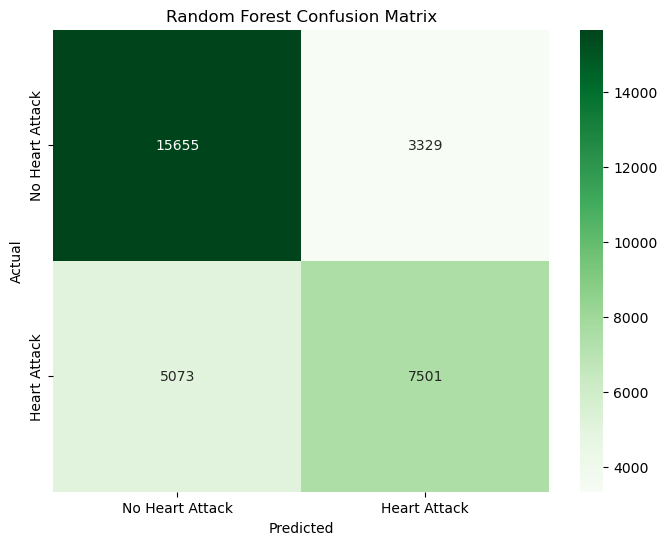

In [52]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# evaluating the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_rf_pred))
# plotting confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_rf_pred), annot=True, fmt='d', cmap='Greens', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


SVM Accuracy: 0.7286900310539325
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79     18984
           1       0.69      0.57      0.63     12574

    accuracy                           0.73     31558
   macro avg       0.72      0.70      0.71     31558
weighted avg       0.73      0.73      0.72     31558

SVM Confusion Matrix:
 [[15787  3197]
 [ 5365  7209]]


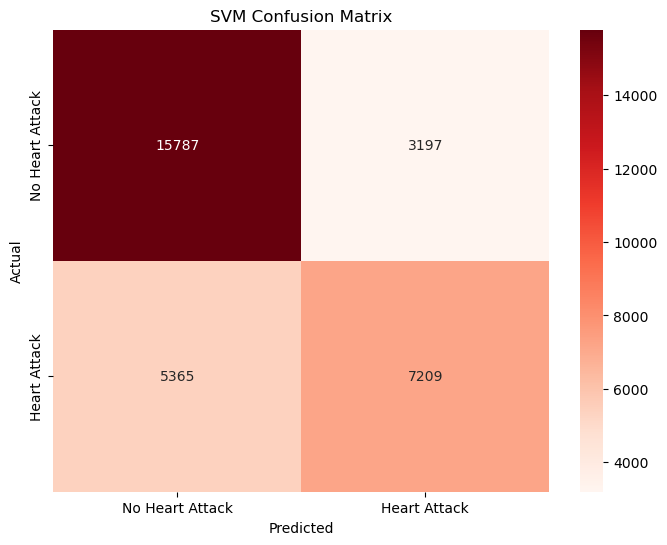

In [53]:
# svm
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
# evaluating the SVM model
y_svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_svm_pred))
print("SVM Classification Report:\n", classification_report(y_test, y_svm_pred))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_svm_pred))
# plotting confusion matrix for SVM
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_svm_pred), annot=True, fmt='d', cmap='Reds', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

d:\master program\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:18:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7297674123835478
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78     18984
           1       0.68      0.61      0.64     12574

    accuracy                           0.73     31558
   macro avg       0.72      0.71      0.71     31558
weighted avg       0.73      0.73      0.73     31558

XGBoost Confusion Matrix:
 [[15391  3593]
 [ 4935  7639]]


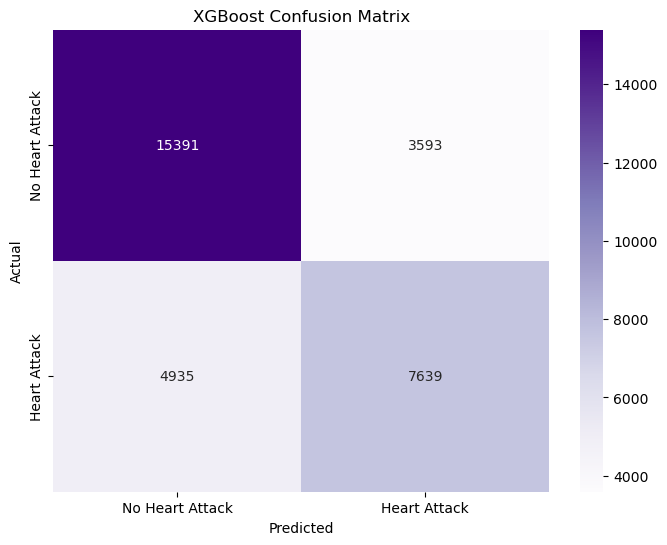

In [54]:
# try XGBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
# evaluating the XGBoost model
y_xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_xgb_pred))
print("XGBoost Classification Report:\n", classification_report(y_test, y_xgb_pred))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))
# plotting confusion matrix for XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_xgb_pred), annot=True, fmt='d', cmap='Purples', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

CatBoost Accuracy: 0.737309081690855
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79     18984
           1       0.70      0.61      0.65     12574

    accuracy                           0.74     31558
   macro avg       0.73      0.72      0.72     31558
weighted avg       0.73      0.74      0.73     31558

CatBoost Confusion Matrix:
 [[15653  3331]
 [ 4959  7615]]


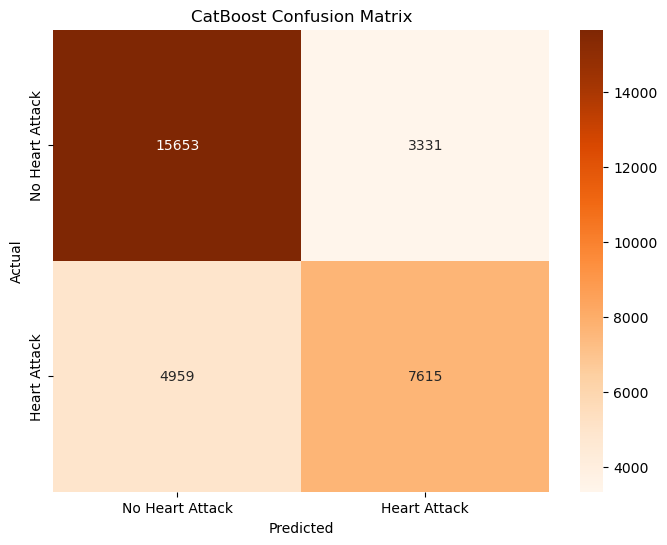

In [55]:
# try CatBoost
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
# evaluating the CatBoost model
y_cat_pred = cat_model.predict(X_test)
print("CatBoost Accuracy:", accuracy_score(y_test, y_cat_pred))
print("CatBoost Classification Report:\n", classification_report(y_test, y_cat_pred))
print("CatBoost Confusion Matrix:\n", confusion_matrix(y_test, y_cat_pred))
# plotting confusion matrix for CatBoost
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_cat_pred), annot=True, fmt='d', cmap='Oranges', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

AdaBoost Accuracy: 0.7401292857595538
AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79     18984
           1       0.71      0.60      0.65     12574

    accuracy                           0.74     31558
   macro avg       0.73      0.72      0.72     31558
weighted avg       0.74      0.74      0.74     31558

AdaBoost Confusion Matrix:
 [[15850  3134]
 [ 5067  7507]]


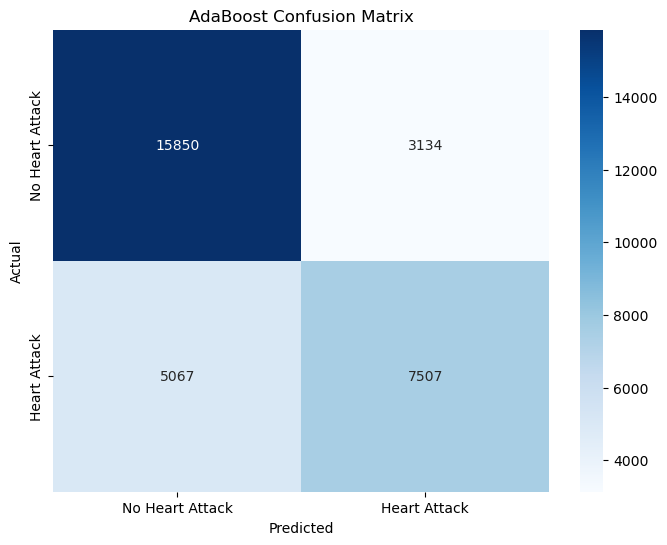

In [56]:
# try AdaBoost
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
# evaluating the AdaBoost model
y_ada_pred = ada_model.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_ada_pred))
print("AdaBoost Classification Report:\n", classification_report(y_test, y_ada_pred))
print("AdaBoost Confusion Matrix:\n", confusion_matrix(y_test, y_ada_pred))
# plotting confusion matrix for AdaBoost
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_ada_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('AdaBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


ANN Accuracy: 0.7069205906584701
ANN Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.78      0.76     18984
           1       0.64      0.59      0.62     12574

    accuracy                           0.71     31558
   macro avg       0.69      0.69      0.69     31558
weighted avg       0.70      0.71      0.70     31558

ANN Confusion Matrix:
 [[14841  4143]
 [ 5106  7468]]


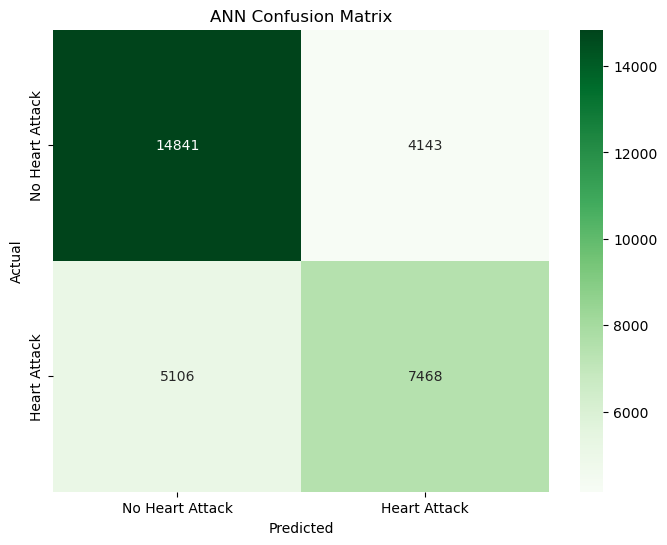

In [57]:
# try ann
from sklearn.neural_network import MLPClassifier
ann_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
ann_model.fit(X_train, y_train)
# evaluating the ANN model
y_ann_pred = ann_model.predict(X_test)
print("ANN Accuracy:", accuracy_score(y_test, y_ann_pred))
print("ANN Classification Report:\n", classification_report(y_test, y_ann_pred))
print("ANN Confusion Matrix:\n", confusion_matrix(y_test, y_ann_pred))
# plotting confusion matrix for ANN
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_ann_pred), annot=True, fmt='d', cmap='Greens', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Epoch 1/50


d:\master program\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3156/3156 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6997 - loss: 0.5661 - val_accuracy: 0.7281 - val_loss: 0.5228
Epoch 2/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7309 - loss: 0.5216 - val_accuracy: 0.7285 - val_loss: 0.5152
Epoch 3/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7301 - loss: 0.5175 - val_accuracy: 0.7310 - val_loss: 0.5121
Epoch 4/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7329 - loss: 0.5111 - val_accuracy: 0.7299 - val_loss: 0.5117
Epoch 5/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7306 - loss: 0.5117 - val_accuracy: 0.7305 - val_loss: 0.5084
Epoch 6/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7324 - loss: 0.5093 - val_accuracy: 0.7300 - val_loss: 0.5073
Epoch 7/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7335 - loss: 0.5070 - val_accuracy: 0.7295 - val_loss: 0.5059
Epoch 8/50
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7313 - loss: 0.5087 - val_accurac

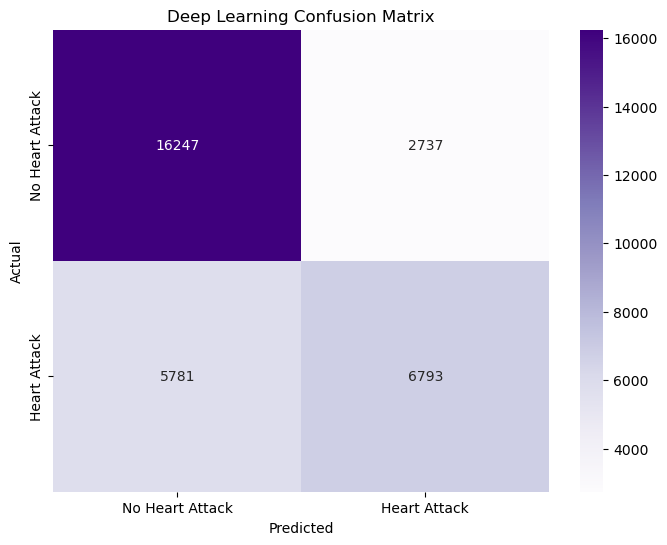

In [58]:
# try deep learning with TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model_dl = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_dl.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)
# evaluating the deep learning model
y_dl_pred = (model_dl.predict(X_test) > 0.5).astype("int32")
print("Deep Learning Accuracy:", accuracy_score(y_test, y_dl_pred))
print("Deep Learning Classification Report:\n", classification_report(y_test, y_dl_pred))
print("Deep Learning Confusion Matrix:\n", confusion_matrix(y_test, y_dl_pred))
# plotting confusion matrix for deep learning
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_dl_pred), annot=True, fmt='d', cmap='Purples', xticklabels=['No Heart Attack', 'Heart Attack'], yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('Deep Learning Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [60]:
# create a summary DataFrame to compare model performances, precision, recall, f1-score, accuracy
summary = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost', 'CatBoost', 'AdaBoost', 'ANN', 'Deep Learning'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_rf_pred),
        accuracy_score(y_test, y_svm_pred),
        accuracy_score(y_test, y_xgb_pred),
        accuracy_score(y_test, y_cat_pred),
        accuracy_score(y_test, y_ada_pred),
        accuracy_score(y_test, y_ann_pred),
        accuracy_score(y_test, y_dl_pred)
    ],
    'Precision': [
        classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_rf_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_svm_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_xgb_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_cat_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_ada_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_ann_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_dl_pred, output_dict=True)['1']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_rf_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_svm_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_xgb_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_cat_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_ada_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_ann_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_dl_pred, output_dict=True)['1']['recall']
    ],
    'F1-Score': [
        classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_rf_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_svm_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_xgb_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_cat_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_ada_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_ann_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_dl_pred, output_dict=True)['1']['f1-score']
    ]
}
summary_df = pd.DataFrame(summary)
summary_df.sort_values(by='Accuracy', ascending=False, inplace=True)
print(summary_df)
# save the summary DataFrame to a CSV file
summary_df.to_csv('model_comparison_summary.csv', index=False)


                 Model  Accuracy  Precision    Recall  F1-Score
5             AdaBoost  0.740129   0.705479  0.597026  0.646737
4             CatBoost  0.737309   0.695688  0.605615  0.647534
1        Random Forest  0.733760   0.692613  0.596548  0.641002
7        Deep Learning  0.730084   0.712802  0.540242  0.614640
3              XGBoost  0.729767   0.680110  0.607523  0.641771
0  Logistic Regression  0.729039   0.690826  0.579132  0.630067
2                  SVM  0.728690   0.692773  0.573326  0.627415
6                  ANN  0.706921   0.643183  0.593924  0.617573
